In [21]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
import shap
import warnings
warnings.filterwarnings('ignore')

user_features = pd.read_csv('../data/processed/user_features.csv')
print(f"Loaded: {user_features.shape}")

Loaded: (962037, 21)


In [22]:
# Cell 2 — Prepare features and label
feature_cols = [
    'unique_tracks', 'unique_artists', 'repeat_rate',
    'artist_loyalty', 'genre_diversity',
    'avg_danceability', 'avg_energy', 'avg_valence',
    'avg_acousticness', 'avg_instrumentalness',
    'avg_tempo', 'avg_loudness', 'avg_track_year'
]
# Note: total_plays excluded — it directly defines the label (would be data leakage)

X = user_features[feature_cols]
y = user_features['low_engagement']

print(f"Features : {X.shape}")
print(f"Label split:\n{y.value_counts()}")

Features : (962037, 13)
Label split:
low_engagement
0    726551
1    235486
Name: count, dtype: int64


In [23]:
# Cell 3 — Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (769629, 13)  Test: (192408, 13)


In [24]:
# Cell 4 — Baseline: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_train_sc, y_train)

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(classification_report(y_test, lr.predict(X_test_sc)))

Logistic Regression AUC: 0.998
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    145311
           1       0.94      0.98      0.96     47097

    accuracy                           0.98    192408
   macro avg       0.97      0.98      0.97    192408
weighted avg       0.98      0.98      0.98    192408



In [25]:
# Cell 5 — Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest AUC: {rf_auc:.3f}")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    145311
           1       1.00      1.00      1.00     47097

    accuracy                           1.00    192408
   macro avg       1.00      1.00      1.00    192408
weighted avg       1.00      1.00      1.00    192408



In [26]:
# Cell 6 — XGBoost (usually best)
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
print(f"XGBoost AUC: {xgb_auc:.3f}")
print(classification_report(y_test, xgb.predict(X_test)))

XGBoost AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    145311
           1       1.00      1.00      1.00     47097

    accuracy                           1.00    192408
   macro avg       1.00      1.00      1.00    192408
weighted avg       1.00      1.00      1.00    192408



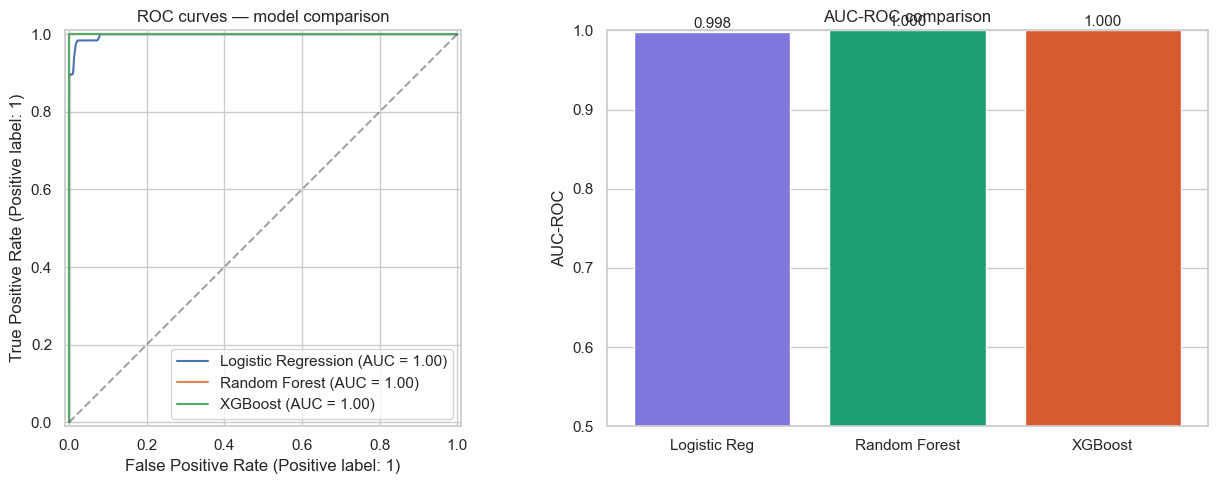

In [27]:
# Cell 7 — Compare all models + ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for model, name, X_ev in [
    (lr,  'Logistic Regression', X_test_sc),
    (rf,  'Random Forest',       X_test),
    (xgb, 'XGBoost',             X_test),
]:
    RocCurveDisplay.from_estimator(model, X_ev, y_test, ax=axes[0], name=name)

axes[0].set_title('ROC curves — model comparison')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)

# Model summary bar
aucs  = [lr_auc, rf_auc, xgb_auc]
names = ['Logistic Reg', 'Random Forest', 'XGBoost']
bars  = axes[1].bar(names, aucs, color=['#7F77DD','#1D9E75','#D85A30'])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC-ROC comparison')
axes[1].set_ylabel('AUC-ROC')
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/plot_model_comparison.png', dpi=120)
plt.show()

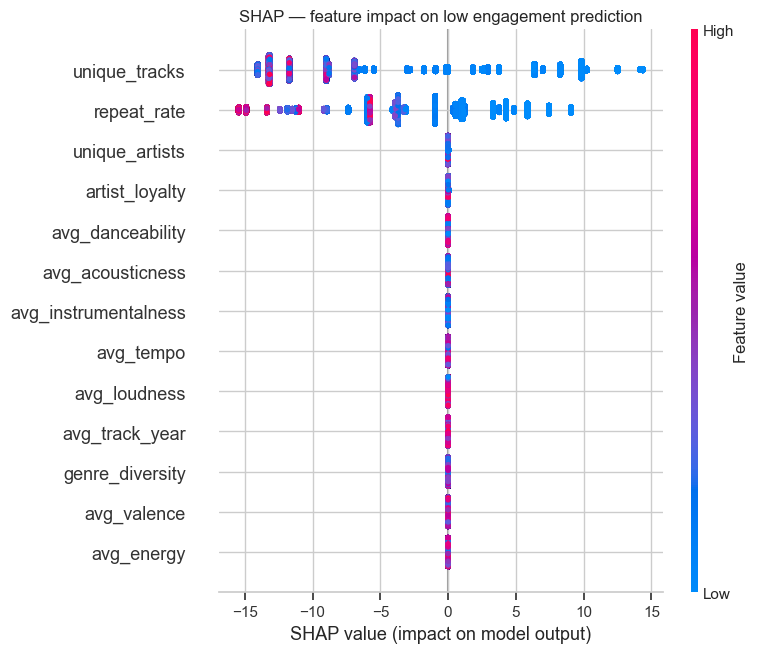

In [29]:
# Cell 8 — SHAP: which features drive low engagement?
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP — feature impact on low engagement prediction')
plt.tight_layout()
plt.savefig('../data/processed/plot_shap.png', dpi=120)
plt.show()

In [30]:
# Cell 9 — Add engagement risk score to all users
user_features['engagement_risk'] = xgb.predict_proba(
    user_features[feature_cols]
)[:,1]

user_features['risk_tier'] = pd.cut(
    user_features['engagement_risk'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

print(user_features['risk_tier'].value_counts())
user_features.to_csv('../data/processed/user_features.csv', index=False)
print("Saved with risk scores ✓")

risk_tier
Low risk       726551
High risk      235486
Medium risk         0
Name: count, dtype: int64
Saved with risk scores ✓
